# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Wendy Oosterhof
* Username: wroosterhof
* Student number: S6328091
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

Text(3, 800, 'Comes from infinity')

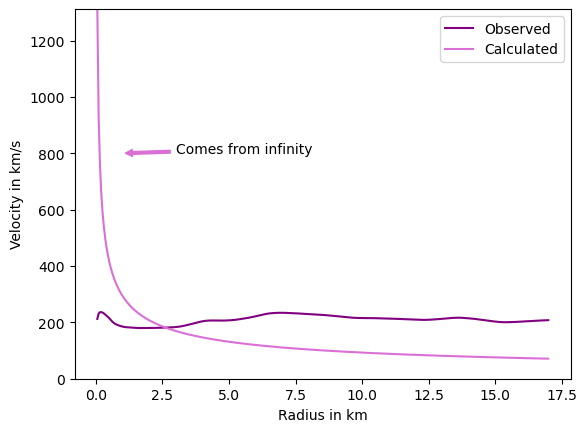

In [2]:
import numpy as np
from scipy.constants import G
from matplotlib import pyplot as plt

data = np.loadtxt("rotcur.dat")
radii = data[1:,0]; velocities = data[1:,1] #Gets rid of the first zero, since that goes to infinity and that can't be used for the plot limits.

M_sun = 1.98847e30  #In kg.
M = 2e10 * M_sun #Puts the masses into kg instead of solar masses.
kpc_m = 3.086e19 #Conversionfactor for kpc to meters.

v_kepler = (np.sqrt((G*M)/(radii*kpc_m)))/1000 #Calculates the velocity according to the 

kepler_data = np.column_stack((radii, v_kepler)) #Makes columns of the two different arrays.
np.savetxt("keplerian_curve.txt", kepler_data) #Saves the data specified above into an textfile.

data2 = np.loadtxt("keplerian_curve.txt") #Loads the data from the textfile before.
kepler_v = data2[:,1] #Slices the data into just taking the second column (the velocities).

#Plotting the figure.
plt.figure()
plt.plot(radii, velocities, color = "purple", label = "Observed")
plt.plot(radii, kepler_v, color = "orchid", label = "Calculated")
plt.xlabel("Radius in km")
plt.ylabel("Velocity in km/s")
plt.ylim(0, np.max(kepler_v))
plt.legend()
plt.annotate(r"Comes from infinity",xy=(1,800),xytext = (3, 800), arrowprops = dict(arrowstyle="simple", color="orchid", lw=1))



The calculated value for the kepler formula is going in a smooth curve downhill, while the observed value is way less smooth and also way less high in the beginning.

<div class="warning" style='background-color:#C9E4FD; color: #004280; border-left: solid #0363BC 6px; border-radius: 4px; padding:2em;'>

For the comment on observation: think of what the graph tells us about the mass distribution in the galaxy for predicted and observed data (also, cute plot!)

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 4.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

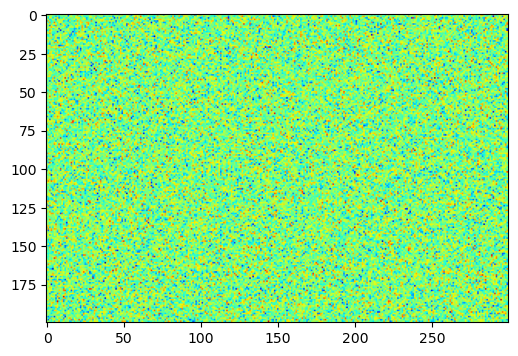

The mean is: 0.000877158982853775, which lies close to the given mean, 0.0, as expected.
The standard deviation is: 0.9598521442162732, which lies close to the given std, 1.0, as expected.


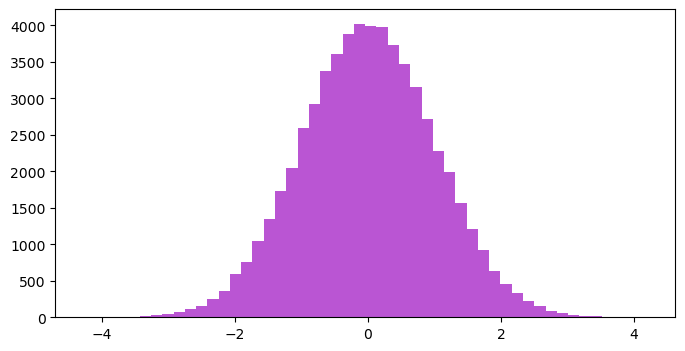

The plot above shows a Gaussian distribution.


In [4]:
import numpy as np

data = np.random.normal(loc = 0.0, scale = 1.0, size = [200, 300]) #Random generation.

plt.figure(figsize=(8,4)) #Gives the figure its size.
plt.imshow(data, cmap = "jet")
slice_pixels = data[50:80, 100:130]  #Takes the data from row 50 till row 80 and column 100 to column 130.
mean = np.mean(slice_pixels) #Calculates the mean.
std = np.std(slice_pixels) #Calculates the standard deviation.
plt.show() #Shows plot when run in terminal.

print(f"The mean is: {mean}, which lies close to the given mean, 0.0, as expected.")
print(f"The standard deviation is: {std}, which lies close to the given std, 1.0, as expected.")

Z_flat = data.ravel() # flattens multidimensional array into a single row

plt.figure(figsize=(8,4))
plt.hist(Z_flat, bins = 50, color = "mediumorchid") #Plots the histogram.
plt.show()
print(f"The plot above shows a Gaussian distribution.")


In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 3.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

AstroEllipse(center=(0, 0), width=3, height=2, angle=0°)
The area of the ellipse with semi major axis 3 and semi minor axis 2 is:  75.40.
The area of the ellipse with semi major axis 3 and semi minor axis 2 is: 31.73.


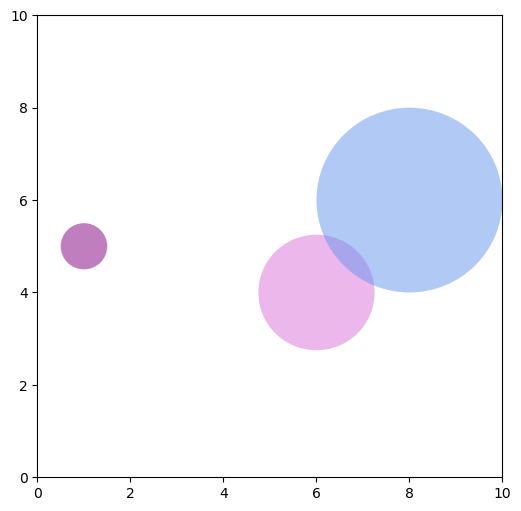

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
            
         # We use the (sort of) astronomical angle where 'angle' defines)
         # the position angle of the major axis of a ring projected onto the sky
         # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
         # the north direction on the sky and the major axis of the receding half of the
         # galaxy (Rots 1975, astron, astrophys 45, 43).
         # Here we assume (!) north is in the positive Y direction.
         # If not, you need to correct the angle for the rotation of the image.
         # Parameter 'position_angle' enters in degrees
         assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
         XY = (xc, yc)                  # MPL requires center as a tuple
         angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
         height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
         width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
         super().__init__(XY, width, height, angle=angle_mpl, **args)

         #Saving the values with their respective names:
         self.xc = xc
         self.yc = yc
         self.semi_major = semi_major
         self.semi_minor = semi_minor
         self.position_angle = position_angle
         self.width = width    # full horizontal axis
         self.height = height  # full vertical axis

        
    def area(self):
        """Calculates the area of an ellips using formula: np.pi * a * b,
        where a is the semi_major axis and b is the semi_minor axis."""
        a = self.width
        b = self.height
        area = np.pi * a * b #Calculates the area using the formula.
        return area
        
    def perimeter(self):
        """Calculates the area of an ellips using the formula: p ≈ π ( 3 (a+b) − √(3a+b) (a+3b) ),
        found when searching Ramanujan's formula for perimeters."""
        a = self.width
        b = self.height
        peri = np.pi * (3 * (a+b) - np.sqrt((3*a+b)*(a+3*b))) #Calculates the perimeter using the formula.
        return peri
        
    def __str__(self):
        """Returns the values of the ellipse in a specified format"""
        return (f"AstroEllipse(center=({self.xc}, {self.yc}), "
                f"width={self.semi_major}, height={self.semi_minor}, angle={self.position_angle}°)")


#Ellipse example
ellipse = AstroEllipse(0, 0, 3, 2, 0, edgecolor='red', facecolor='none') #Specifying ellips.


#All the print examples.
print(ellipse)
print(f"The area of the ellipse with semi major axis 3 and semi minor axis 2 is:  {ellipse.area():.2f}.")
print(f"The area of the ellipse with semi major axis 3 and semi minor axis 2 is: {ellipse.perimeter():.2f}.")

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **kwargs):
        """
        xc, yc : center coordinates
        radius : radius of the circle
        kwargs : any matplotlib patch options (edgecolor, facecolor, etc.)
        """
        # A circle is an ellipse with equal semi-major and semi-minor axes, so we can just give both semi axis to the radius.
        super().__init__(xc, yc, semi_major=radius, semi_minor=radius, position_angle=0, **kwargs) #super() : if anything changes in parent class this one changes aswell.

#Some circle examples:
circle1 = MyCircle(6, 4, 1.25,facecolor = "Orchid", alpha = 0.5) #xc, yc, major, minor, rotation, color.
circle2 = MyCircle(1,5,0.5, facecolor = "purple", alpha = 0.5)
circle3 = MyCircle(8,6,2, facecolor = "cornflowerblue", alpha = 0.5)

#Plotting said circles.
plt.figure(figsize=(6,6)) #Made the figure square so you can also see that the shapes are spheres and they don't look like ellipses.

#Setting the limits in square form, so the shapes don't get distorted.
plt.xlim(0,10)
plt.ylim(0,10)

#gca = get current axis and the add_patch add the ellipse shape to these axis / plots the actual ellipse.
plt.gca().add_patch(circle1) 
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)
plt.show()        

<div class="warning" style='background-color:#FBD5D9; color: #B21129; border-left: solid #E20035 6px; border-radius: 4px; padding:2em;'>

The area (so also the perimeter) calculation is off. Think about do you calculate the area using the full axes, or semi-axes?  <b>-1 pt</b>

Also, in the example for a=3, b=2 you print the area and perimeter but both print statements say area) 

Print results of the ``__str__()``  <b>-0.5 pt</b>

The circles should have random origins and radii <b>-0.5 pt</b>



In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 4.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

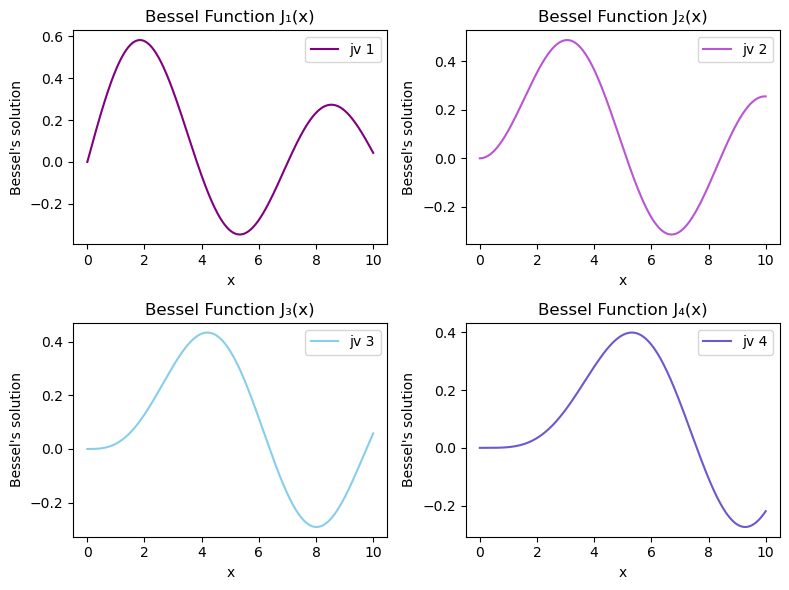

In [8]:
from scipy.special import jv
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(0,10,500) #Creates the values for x.
a = np.array([1,2,3,4])

fig, axes = plt.subplots(2, 2, figsize=(8, 6)) #Creates the subplots with the 2x2 form.

#Creating the first plot.
y1 = jv(1,x) #Calculates the y for the plot.
axes[0,0].plot(x, y1, color = "purple", label ="jv 1") #Plots the graph itself.
axes[0,0].legend() #Plots the legend.
axes[0,0].set_title("Bessel Function J₁(x)") #Sets the titel of the subplot.
axes[0,0].set_xlabel("x") #x label.
axes[0,0].set_ylabel("Bessel's solution") #y label.
#Extra: the axes[0,0] specifies that it's about the plot left top, since you count the
# pixels from top left to bottom right and start with index 0.


#Creating the second plot.
y2 = jv(2,x)
axes[0,1].plot(x,y2, color = "mediumorchid", label ="jv 2")
axes[0,1].legend()
axes[0,1].set_title("Bessel Function J₂(x)")
axes[0,1].set_xlabel("x")
axes[0,1].set_ylabel("Bessel's solution")

#Creating the third plot.
y3 = jv(3,x)
axes[1,0].plot(x,y3, color = "skyblue", label ="jv 3")
axes[1,0].legend()
axes[1,0].set_title("Bessel Function J₃(x)")
axes[1,0].set_xlabel("x")
axes[1,0].set_ylabel("Bessel's solution")

#Creating the last plot.
y4 = jv(4,x)
axes[1,1].plot(x, y4, color = "slateblue", label ="jv 4")
axes[1,1].legend()
axes[1,1].set_title("Bessel Function J₄(x)")
axes[1,1].set_xlabel("x")
axes[1,1].set_ylabel("Bessel's solution")

fig.tight_layout() #Makes sure things don't overlap. This for example fixed that the y label was in a different graph.

fig.show()
fig.savefig("bessel.png", transparent = True) #Saves the figure as a transparent (transparent = True) png.




    


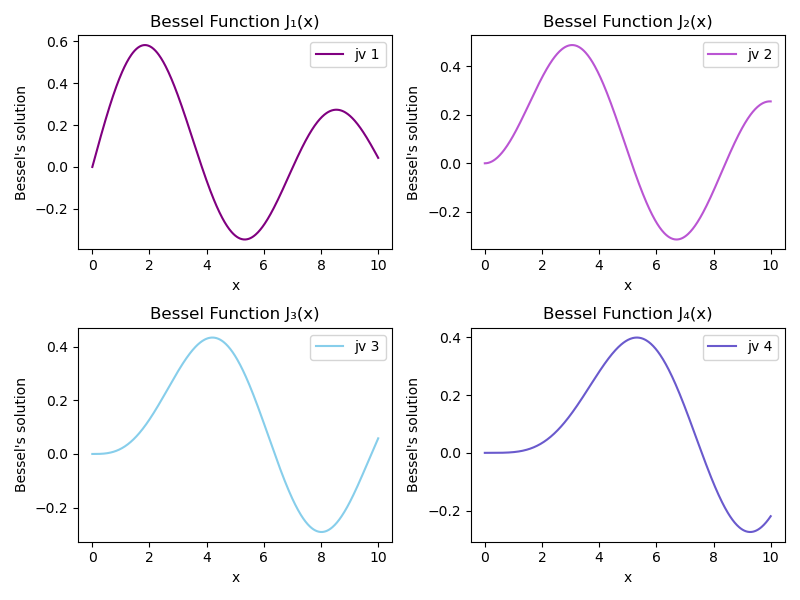

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 3.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

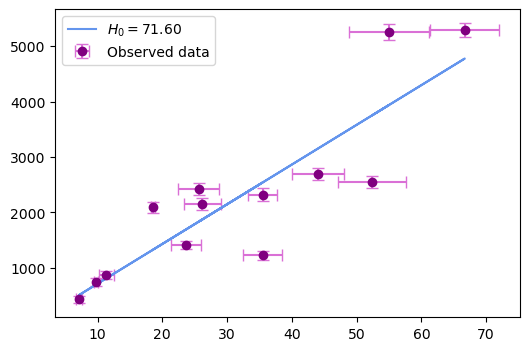

In [10]:


#d(Mpc)    v(km/s)    error in d    error in v
 #   ==============================================
 #   18.49      2094.75    0.3           100
  #  35.48      2320.87    2.2           120
  #  ........
data = np.array([
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ])
data = data.reshape(-1, 4) #Reshapes the data array into rows of 4.
d, v, d_err, v_err = data[:,0],data[:,1],data[:,2],data[:,3]

#Calculating H0 using fitting of least squares and through the origin. 
H0 = np.sum(d * v) / np.sum(d**2)  # calculates the slope
v_H0 = d * H0 #Calculating the points of the line using the newly calculated slope.

fig, ax = plt.subplots(figsize=(6,4))
ax.errorbar(d, v, xerr=d_err, yerr=v_err, fmt='o',color = "purple", ecolor='orchid', capsize=4, label='Observed data') #plots it with error bars: d_err and v_err from the original data.
ax.plot(d, v_H0, color = "cornflowerblue", label = rf"$H_0 ={H0:.2f}$ ")
ax.legend()
plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 2.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 16.0.  Task Grade = 8.9
